# XGBoost Model + Feature Selection

## 1. Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler # Import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report
from google.colab import files

## 2. Loading and Preparing the Data
Here, we will load the dataset, clean it, and split the data into features (X) and labels (y).

In [ ]:
# Upload file from local system
uploaded = files.upload()

Saving Molecules_Toxicity_Classification.csv to Molecules_Toxicity_Classification (4).csv


In [ ]:
data = pd.read_csv("Molecules_Toxicity_Classification (4).csv")
data.drop("Unnamed: 0", inplace=True, axis=1)
encoder = LabelEncoder()
data["Class"] = encoder.fit_transform(data["Class"])
X = data.drop("Class", axis=1)
y = data["Class"]

## Split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.07, shuffle=True, random_state=42)

## 4. Feature Scaling

In [ ]:
scaler = RobustScaler() # used better for outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Handling Class Imbalance with Random Oversampling
Since the data may be imbalanced, we will use Random Oversampling to balance the classes in the training set.

In [ ]:
print("Before resampling class distribution:")
print(y_train.value_counts())
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_scaled, y_train)
print("\nAfter resampling class distribution:")
print(y_train_resampled.value_counts())

Before resampling class distribution:
Class
0    100
1     47
Name: count, dtype: int64

After resampling class distribution:
Class
0    100
1    100
Name: count, dtype: int64


## 6. Feature Selection with XGBoost
To improve the model’s performance, we will perform feature selection (feature importance + RFE) using XGBoost to keep only the top 15 features based on importance.

Feature Importance

In [ ]:
xgb_selector = xgb.XGBClassifier(random_state=42)
xgb_selector.fit(X, y) # Using original data for feature importance

importances = xgb_selector.feature_importances_
important_features_idx = np.argsort(importances)[::-1][:15]
selected_features = X.columns[important_features_idx]

print("Selected top 15 features:\n", selected_features)

Selected top 15 features:
 Index(['piPC2', 'ATSC1c', 'SpDiam_Dt', 'ATS5e', 'ATSC5i', 'ETA_EtaP_F_L',
       'SpAD_Dt', 'AATS5m', 'ATS0m', 'ETA_Epsilon_4', 'minaaN', 'MAXDN',
       'GATS2p', 'SpMin6_Bhi', 'MPC5'],
      dtype='object')


In [ ]:
# Reduce to selected features AFTER scaling and oversampling
X_train_selected = X_train_resampled[:, important_features_idx]
X_test_selected = X_test_scaled[:, important_features_idx]

RFE

In [ ]:
# Choose XGBoost as the estimator for RFE
estimator = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

We have tried:
1. 30 features => cv = 83%, test accuracy = 60%
2. 15 features => cv = 86%, test accuracy = 62%
overfitting
3. 7 features => cv = 83%, test accuracy = 59%

In [ ]:
# Define the number of features to select
n_features_to_select = 15

In [ ]:
# Initialize RFE
rfe = RFE(estimator, n_features_to_select=n_features_to_select)

In [ ]:
# Fit RFE on the scaled training data
rfe.fit(X_train_scaled, y_train)

In [ ]:
# Get the selected features
selected_features_rfe = X_train.columns[rfe.support_]
print("Selected features by RFE:\n", selected_features_rfe)

In [ ]:
# Transform the training and testing data to include only the selected features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

In [ ]:
# Handle Class Imbalance with Random Oversampling (after feature selection - RFE)
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_rfe, y_train)

## 7. Hyperparameter Tuning with RandomizedSearchCV
We will perform Randomized Search to find the best hyperparameters for the XGBoost model.

In [ ]:
params = {"learning_rate":[0.01, 0.1, 0.8, 1], "n_estimators":[50, 100, 200, 300], "gamma":[0, 0.1, 1, 5, 10],
          "max_depth":[2, 4, 6, 8], "max_delta_step":[0, 1, 5, 10], "reg_lambda":[0.5, 1, 2, 5, 10], "reg_alpha":[0, 0.1, 0.5, 1, 5]}

clf = RandomizedSearchCV(xgb.XGBClassifier(random_state=42), params, n_iter=30, cv=8, random_state=0, scoring='f1_weighted') # Using f1_weighted as scoring metric
clf.fit(X_train_selected, y_train_resampled)

print("\nBest parameters found by RandomizedSearchCV:")
print(clf.best_params_)


Best parameters found by RandomizedSearchCV:
{'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 6, 'max_delta_step': 0, 'learning_rate': 0.1, 'gamma': 1}


## 8. Model Evaluation with Cross-Validation
We will evaluate the model using cross-validation (CV) to assess its stability and performance.

In [ ]:
# Get the best cross-validation score
best_cv_score = clf.best_score_
print(f"\nBest cross-validation F1-weighted score: {best_cv_score:.4f}")

Average CV F1-Score: 0.7441


# 9. Retraining the Model on Full Training Set with Best Hyperparameters


Final Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.60      0.75      0.67         4

    accuracy                           0.75        12
   macro avg       0.73      0.75      0.73        12
weighted avg       0.77      0.75      0.76        12



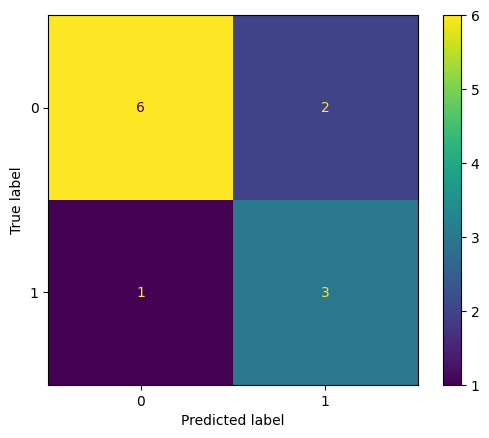

In [ ]:
final = xgb.XGBClassifier(**clf.best_params_, random_state=42)
final.fit(X_train_selected, y_train_resampled)

# Predict and evaluate on the test set
y_final_pred = final.predict(X_test_selected)
print("\nFinal Classification Report:")
print(classification_report(y_test, y_final_pred, zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_final_pred)).plot()
plt.show()

Final Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.75      0.75      0.75         4

    accuracy                           0.83        12
   macro avg       0.81      0.81      0.81        12
weighted avg       0.83      0.83      0.83        12



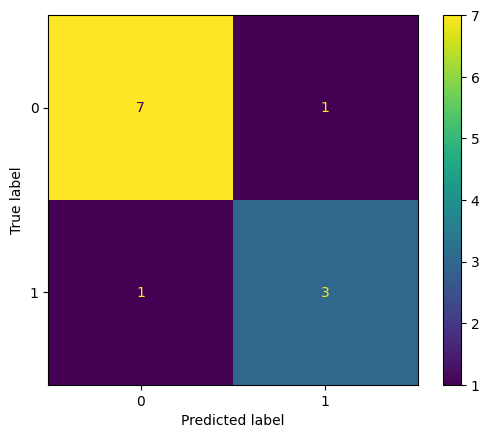

In [ ]:
print("Final Classification Report:")
print(classification_report(y_test, y_final_pred))

# Plot the confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_final_pred)).plot()

## 10. Model Prediction Function
This function will take new test data, apply necessary transformations, and return the predictions.

In [ ]:
def get_predictions(test_data):
    test_data_processed = test_data.drop("Unnamed: 0", inplace=False, axis=1, errors='ignore')
    test_data_selected = test_data_processed[selected_features]
    test_data_scaled = scaler.transform(test_data_selected)
    return final.predict(test_data_scaled)